# Phase 3 — ETL (Extract · Transform · Load)

---
**Objectif :** Nettoyer les données, réaliser les jointures entre tables, créer les variables métier, et produire un dataset analytique final (`customer_analytics.csv`) où **chaque ligne représente un client unique**.

Ce dataset sera la base de toutes les phases suivantes (EDA, clustering, modélisation ML).

---

## 0. Configuration & Imports

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("Imports OK")

Imports OK


In [2]:
# ============================================================
# CHEMINS — identiques à la Phase 2
# ============================================================
# Racine commune
DATA_ROOT = r"C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD"  # <-- modifiez ce chemin si nécessaire

# --- Olist ---
OLIST_DIR = os.path.join(DATA_ROOT, "Brazilian E-Commerce Public Dataset by Olist/")

# --- Instacart ---
INSTACART_DIR = os.path.join(DATA_ROOT, "Instacart Market Basket Analysis/")

# --- Amazon ---
AMAZON_DIR = os.path.join(DATA_ROOT, "Amazon Product Reviews Dataset/")

print("Chemins configurés")
print(f"  Olist     : {OLIST_DIR}")
print(f"  Instacart : {INSTACART_DIR}")
print(f"  Amazon    : {AMAZON_DIR}")

Chemins configurés
  Olist     : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Brazilian E-Commerce Public Dataset by Olist/
  Instacart : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Instacart Market Basket Analysis/
  Amazon    : C:\Users\AORUS\Documents\ENSIAS 2A\projetDDD\Amazon Product Reviews Dataset/


---
## 1. EXTRACT — Rechargement des données brutes

In [4]:
# ============================================================
# EXTRACT — Chargement de toutes les tables brutes
# Même chargement qu'en Phase 2, regroupé ici pour autonomie
# ============================================================

# --- Olist ---
olist_customers  = pd.read_csv(os.path.join(OLIST_DIR, 'olist_customers_dataset.csv'))
olist_orders     = pd.read_csv(os.path.join(OLIST_DIR, 'olist_orders_dataset.csv'))
olist_items      = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_items_dataset.csv'))
olist_payments   = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_payments_dataset.csv'))
olist_reviews    = pd.read_csv(os.path.join(OLIST_DIR, 'olist_order_reviews_dataset.csv'))
olist_products   = pd.read_csv(os.path.join(OLIST_DIR, 'olist_products_dataset.csv'))
olist_cat_trans  = pd.read_csv(os.path.join(OLIST_DIR, 'product_category_name_translation.csv'))

# --- Instacart ---
insta_orders          = pd.read_csv(os.path.join(INSTACART_DIR, 'orders.csv'))
insta_order_products  = pd.read_csv(os.path.join(INSTACART_DIR, 'order_products__prior.csv'))
insta_products        = pd.read_csv(os.path.join(INSTACART_DIR, 'products.csv'))
insta_aisles          = pd.read_csv(os.path.join(INSTACART_DIR, 'aisles.csv'))
insta_departments     = pd.read_csv(os.path.join(INSTACART_DIR, 'departments.csv'))

# --- Amazon ---
amazon_reviews = pd.read_csv(os.path.join(AMAZON_DIR, 'amazon_review.csv'))

print(" Extract terminé — toutes les tables chargées")

 Extract terminé — toutes les tables chargées


---
## 2. TRANSFORM — Nettoyage des données

### 2.1 Nettoyage Olist Orders

In [5]:
# ============================================================
# NETTOYAGE : olist_orders
# ============================================================

print(f"Avant nettoyage : {olist_orders.shape}")

# --- Étape 1 : Suppression des doublons complets ---
olist_orders = olist_orders.drop_duplicates()

# --- Étape 2 : Conversion des colonnes de dates en datetime ---
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    olist_orders[col] = pd.to_datetime(olist_orders[col], errors='coerce')
    # errors='coerce' → les valeurs non-parsables deviennent NaT au lieu de lever une erreur

# --- Étape 3 : Filtrer uniquement les commandes livrées ---
# Seules les commandes "delivered" ont des dates de livraison complètes
# et des informations fiables sur le comportement client
olist_orders_delivered = olist_orders[olist_orders['order_status'] == 'delivered'].copy()

# --- Étape 4 : Supprimer les lignes avec dates de livraison manquantes ---
olist_orders_delivered = olist_orders_delivered.dropna(
    subset=['order_delivered_customer_date', 'order_purchase_timestamp']
)

print(f"Après nettoyage (livrées seulement) : {olist_orders_delivered.shape}")
print(f"  → {olist_orders.shape[0] - olist_orders_delivered.shape[0]:,} commandes exclues (non livrées ou dates manquantes)")

Avant nettoyage : (99441, 8)
Après nettoyage (livrées seulement) : (96470, 8)
  → 2,971 commandes exclues (non livrées ou dates manquantes)


### 2.2 Nettoyage Olist Payments

In [6]:
# ============================================================
# NETTOYAGE : olist_payments
# Un order_id peut avoir plusieurs lignes (paiements multiples)
# → On agrège par order_id pour obtenir le montant total
# ============================================================

print(f"Avant agrégation payments : {olist_payments.shape}")

# Suppression doublons complets
olist_payments = olist_payments.drop_duplicates()

# Agrégation : somme du montant total payé par commande
# et comptage du nombre de versements (indicateur comportemental)
payments_agg = olist_payments.groupby('order_id').agg(
    total_payment   = ('payment_value', 'sum'),       # Montant total payé pour cette commande
    n_installments  = ('payment_installments', 'max'), # Max mensualités choisies
    payment_type    = ('payment_type', lambda x: x.mode()[0])  # Type de paiement le plus fréquent
).reset_index()

print(f"Après agrégation : {payments_agg.shape}")
print(f"  Colonnes : {list(payments_agg.columns)}")
display(payments_agg.head(3))

Avant agrégation payments : (103886, 5)
Après agrégation : (99440, 4)
  Colonnes : ['order_id', 'total_payment', 'n_installments', 'payment_type']


,order_id,total_payment,n_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card


### 2.3 Nettoyage Olist Reviews

In [7]:
# ============================================================
# NETTOYAGE : olist_reviews
# On garde uniquement la colonne numérique review_score
# Les colonnes textuelles ont trop de NaN pour être exploitables en ML
# ============================================================

print(f"Avant nettoyage reviews : {olist_reviews.shape}")

# Suppression des doublons sur review_id
olist_reviews = olist_reviews.drop_duplicates(subset='review_id')

# Supprimer les avis sans note (review_score NaN)
olist_reviews = olist_reviews.dropna(subset=['review_score'])

# S'assurer que review_score est bien un entier entre 1 et 5
olist_reviews['review_score'] = olist_reviews['review_score'].astype(int)
olist_reviews = olist_reviews[olist_reviews['review_score'].between(1, 5)]

# Garder seulement les colonnes utiles
olist_reviews_clean = olist_reviews[['order_id', 'review_score']].copy()

# Pour les commandes avec plusieurs avis, prendre la moyenne
reviews_agg = olist_reviews_clean.groupby('order_id').agg(
    avg_review_score = ('review_score', 'mean')
).reset_index()

print(f"Après nettoyage : {reviews_agg.shape}")
display(reviews_agg.head(3))

Avant nettoyage reviews : (99224, 7)
Après nettoyage : (98167, 2)


,order_id,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0


### 2.4 Nettoyage Instacart

In [8]:
# ============================================================
# NETTOYAGE : instacart_orders
# ============================================================

print(f"Avant nettoyage insta_orders : {insta_orders.shape}")

# Suppression doublons
insta_orders = insta_orders.drop_duplicates()

# Filtrer sur le sous-ensemble 'prior' (historique d'achat)
# 'train' et 'test' sont des sous-ensembles pour la compétition Kaggle originale
insta_orders_prior = insta_orders[insta_orders['eval_set'] == 'prior'].copy()

# Imputation de days_since_prior_order :
# NaN = première commande → on impute par 0 (aucun délai précédent)
insta_orders_prior['days_since_prior_order'] = insta_orders_prior['days_since_prior_order'].fillna(0)

print(f"Après filtrage 'prior' : {insta_orders_prior.shape}")

Avant nettoyage insta_orders : (3421083, 7)
Après filtrage 'prior' : (3214874, 7)


In [9]:
# ============================================================
# NETTOYAGE : amazon_reviews
# ============================================================

print(f"Avant nettoyage amazon : {amazon_reviews.shape}")

# Suppression des doublons
amazon_reviews = amazon_reviews.drop_duplicates()

# Garder uniquement les lignes avec une note valide
if 'overall' in amazon_reviews.columns:
    amazon_reviews = amazon_reviews.dropna(subset=['overall'])
    amazon_reviews['overall'] = amazon_reviews['overall'].astype(float)
    amazon_reviews = amazon_reviews[amazon_reviews['overall'].between(1, 5)]

print(f"Après nettoyage amazon : {amazon_reviews.shape}")

Avant nettoyage amazon : (4915, 12)
Après nettoyage amazon : (4915, 12)


---
## 3. TRANSFORM — Jointures & Création des Variables Métier

### 3.1 Pipeline de jointure Olist

```
olist_customers
       ↓  (customer_id)
olist_orders_delivered
       ↓  (order_id)
payments_agg
       ↓  (order_id)
reviews_agg
       ↓  (order_id)
olist_items → agrégé par order_id
              ↓
   Dataset intermédiaire order-level
              ↓
   Agrégation par customer_unique_id
              ↓
   customer_analytics (Olist)
```

In [10]:
# ============================================================
# JOINTURE 1 : Orders ← → Customers
# Ajout de customer_unique_id aux commandes
# ============================================================

# Sélection des colonnes nécessaires des customers
customers_slim = olist_customers[['customer_id', 'customer_unique_id', 'customer_state']]

# Jointure left : toutes les commandes livrées + infos client
orders_with_customers = olist_orders_delivered.merge(
    customers_slim,
    on='customer_id',
    how='left'
)

print(f"Orders + Customers : {orders_with_customers.shape}")

✅ Orders + Customers : (96470, 10)


In [11]:
# ============================================================
# JOINTURE 2 : Orders ← → Payments
# ============================================================

orders_with_payments = orders_with_customers.merge(
    payments_agg,
    on='order_id',
    how='left'
)

print(f" Orders + Payments : {orders_with_payments.shape}")

 Orders + Payments : (96470, 13)


In [12]:
# ============================================================
# JOINTURE 3 : Orders ← → Reviews
# ============================================================

orders_full = orders_with_payments.merge(
    reviews_agg,
    on='order_id',
    how='left'
)

print(f" Orders + Reviews : {orders_full.shape}")

 Orders + Reviews : (96470, 14)


In [13]:
# ============================================================
# AGRÉGATION ITEMS : calcul de la taille du panier par commande
# ============================================================

# Nombre d'articles distincts par commande et somme des prix produits
items_agg = olist_items.groupby('order_id').agg(
    basket_size      = ('order_item_id', 'count'),   # Nombre d'articles dans la commande
    items_price_sum  = ('price', 'sum'),              # Prix total des articles (hors frais de port)
    freight_sum      = ('freight_value', 'sum')       # Total frais de port
).reset_index()

# Jointure sur les commandes
orders_full = orders_full.merge(
    items_agg,
    on='order_id',
    how='left'
)

print(f" Orders + Items : {orders_full.shape}")
display(orders_full.head(3))

 Orders + Items : (96470, 17)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,total_payment,n_installments,payment_type,avg_review_score,basket_size,items_price_sum,freight_sum
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,1.0,voucher,4.0,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,141.46,1.0,boleto,4.0,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,3.0,credit_card,5.0,1,159.90,19.22


### 3.2 Création des variables métier au niveau commande

In [14]:
# ============================================================
# VARIABLES MÉTIER — NIVEAU COMMANDE
# ============================================================

# --- Delivery_Delay : retard de livraison en jours ---
# Négatif = livré en avance, Positif = livré en retard
orders_full['delivery_delay_days'] = (
    orders_full['order_delivered_customer_date'] -
    orders_full['order_estimated_delivery_date']
).dt.days

# --- Actual_Delivery_Time : durée réelle de livraison (achat → livraison) ---
orders_full['actual_delivery_days'] = (
    orders_full['order_delivered_customer_date'] -
    orders_full['order_purchase_timestamp']
).dt.days

# --- Is_Late : indicateur binaire de retard ---
# 1 si livré après la date estimée, 0 sinon
orders_full['is_late'] = (orders_full['delivery_delay_days'] > 0).astype(int)

# --- Order_Month : mois de la commande (pour analyses temporelles) ---
orders_full['order_month'] = orders_full['order_purchase_timestamp'].dt.to_period('M')

# --- Order_Year : année de la commande ---
orders_full['order_year'] = orders_full['order_purchase_timestamp'].dt.year

print(" Variables métier ordre créées :")
print(orders_full[['order_id', 'delivery_delay_days', 'actual_delivery_days', 
                    'is_late', 'order_month']].head(5).to_string())

 Variables métier ordre créées :
                           order_id  delivery_delay_days  actual_delivery_days  is_late order_month
0  e481f51cbdc54678b7cc49136f2d6af7                   -8                     8        0     2017-10
1  53cdb2fc8bc7dce0b6741e2150273451                   -6                    13        0     2018-07
2  47770eb9100c2d0c44946d9cf07ec65d                  -18                     9        0     2018-08
3  949d5b44dbf5de918fe9c16f97b45f8a                  -13                    13        0     2017-11
4  ad21c59c0840e6cb83a9ceb5573f8159                  -10                     2        0     2018-02


### 3.3 Agrégation au niveau client (Olist)

In [15]:
# ============================================================
# AGRÉGATION CLIENT — Olist
# Chaque ligne = 1 client unique (customer_unique_id)
# Chaque colonne = une caractéristique comportementale ou financière
# ============================================================

# Date de référence pour calculer la récence (Recency)
# On prend la date max de l'ensemble + 1 jour comme date de snapshot
SNAPSHOT_DATE = orders_full['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Date snapshot : {SNAPSHOT_DATE.date()}")

# Agrégation de toutes les métriques par client
customer_olist = orders_full.groupby('customer_unique_id').agg(
    
    # --- Métriques RFM ---
    recency_days      = ('order_purchase_timestamp',
                         lambda x: (SNAPSHOT_DATE - x.max()).days),  # Jours depuis dernier achat
    nb_orders         = ('order_id', 'nunique'),                      # Fréquence (nb commandes)
    total_spent       = ('total_payment', 'sum'),                     # Montant total (Monetary)

    # --- Métriques financières ---
    avg_order_value   = ('total_payment', 'mean'),                    # Panier moyen
    max_order_value   = ('total_payment', 'max'),                     # Commande max

    # --- Métriques panier ---
    avg_basket_size   = ('basket_size', 'mean'),                      # Nb articles moyen / commande
    total_items       = ('basket_size', 'sum'),                       # Total articles achetés

    # --- Métriques livraison ---
    avg_delivery_days = ('actual_delivery_days', 'mean'),             # Délai livraison moyen
    avg_delay         = ('delivery_delay_days', 'mean'),              # Retard moyen (peut être négatif)
    late_rate         = ('is_late', 'mean'),                          # Proportion de commandes en retard

    # --- Métriques satisfaction ---
    avg_review_score  = ('avg_review_score', 'mean'),                 # Note moyenne

    # --- Métriques temporelles ---
    first_order_date  = ('order_purchase_timestamp', 'min'),          # Date première commande
    last_order_date   = ('order_purchase_timestamp', 'max'),          # Date dernière commande

    # --- Géographie ---
    customer_state    = ('customer_state', 'first'),                  # État du client

).reset_index()

print(f" Agrégation client Olist : {customer_olist.shape}")
print(f"   Colonnes : {list(customer_olist.columns)}")

Date snapshot : 2018-08-30
 Agrégation client Olist : (93350, 15)
   Colonnes : ['customer_unique_id', 'recency_days', 'nb_orders', 'total_spent', 'avg_order_value', 'max_order_value', 'avg_basket_size', 'total_items', 'avg_delivery_days', 'avg_delay', 'late_rate', 'avg_review_score', 'first_order_date', 'last_order_date', 'customer_state']


In [16]:
# ============================================================
# VARIABLES MÉTIER SUPPLÉMENTAIRES — NIVEAU CLIENT
# ============================================================

# --- Purchase_Frequency : commandes par mois actif ---
# Durée d'activité = nb jours entre première et dernière commande
customer_olist['active_days'] = (
    customer_olist['last_order_date'] - customer_olist['first_order_date']
).dt.days

# Pour les clients avec une seule commande, active_days = 0 → on met 1 pour éviter division par zéro
customer_olist['purchase_frequency'] = customer_olist['nb_orders'] / (
    customer_olist['active_days'].replace(0, 1) / 30
)  # En commandes par mois

# --- Is_Loyal : variable cible pour la modélisation ML ---
# 1 = client fidèle (a effectué plus d'une commande)
# 0 = client one-shot (une seule commande → risque de désengagement)
customer_olist['is_loyal'] = (customer_olist['nb_orders'] > 1).astype(int)

# --- High_Value : client à fort potentiel ---
# 1 = au-dessus de la médiane de dépense totale
median_spend = customer_olist['total_spent'].median()
customer_olist['is_high_value'] = (customer_olist['total_spent'] >= median_spend).astype(int)

# --- Avg review score : imputation des NaN ---
# Pour les clients sans avis, on impute par la médiane globale
median_review = customer_olist['avg_review_score'].median()
customer_olist['avg_review_score'] = customer_olist['avg_review_score'].fillna(median_review)

print("Variables métier client créées")
print(f"   Clients fidèles (is_loyal=1) : {customer_olist['is_loyal'].sum():,} ({customer_olist['is_loyal'].mean()*100:.1f}%)")
print(f"   Clients one-shot (is_loyal=0) : {(customer_olist['is_loyal']==0).sum():,} ({(customer_olist['is_loyal']==0).mean()*100:.1f}%)")

Variables métier client créées
   Clients fidèles (is_loyal=1) : 2,801 (3.0%)
   Clients one-shot (is_loyal=0) : 90,549 (97.0%)


### 3.4 Enrichissement Instacart — Métriques comportementales

In [17]:
# ============================================================
# AGRÉGATION CLIENT — Instacart
# Métriques sur les habitudes d'achat (récurrence, délai réachat)
# ============================================================

# Jointure orders_prior avec order_products pour compter les articles
insta_with_products = insta_orders_prior.merge(
    insta_order_products.groupby('order_id').agg(
        nb_products_per_order = ('product_id', 'count'),     # Nb produits par commande
        nb_reordered          = ('reordered', 'sum')          # Nb produits déjà commandés avant
    ).reset_index(),
    on='order_id',
    how='left'
)

# Agrégation par user_id (client Instacart)
customer_instacart = insta_with_products.groupby('user_id').agg(
    insta_nb_orders             = ('order_id', 'nunique'),              # Fréquence totale
    insta_avg_days_between      = ('days_since_prior_order', 'mean'),   # Délai moyen réachat
    insta_avg_basket_size       = ('nb_products_per_order', 'mean'),    # Panier moyen (articles)
    insta_reorder_rate          = ('nb_reordered',
                                   lambda x: x.sum() / insta_with_products.loc[
                                       x.index, 'nb_products_per_order'].sum()
                                   if insta_with_products.loc[
                                       x.index, 'nb_products_per_order'].sum() > 0 else 0),
    insta_preferred_day         = ('order_dow', lambda x: x.mode()[0]),  # Jour préféré
    insta_preferred_hour        = ('order_hour_of_day', 'mean'),          # Heure moyenne d'achat
).reset_index()

print(f"Agrégation client Instacart : {customer_instacart.shape}")
display(customer_instacart.head(3))

Agrégation client Instacart : (206209, 7)


,user_id,insta_nb_orders,insta_avg_days_between,insta_avg_basket_size,insta_reorder_rate,insta_preferred_day,insta_preferred_hour
0,1,10,17.600000,5.900000,0.694915,1,10.300000
1,2,14,14.142857,13.928571,0.476923,1,10.571429
2,3,12,11.083333,7.333333,0.625000,0,16.416667


### 3.5 Enrichissement Amazon — Score de satisfaction global

In [18]:
# ============================================================
# AGRÉGATION AMAZON — métriques satisfaction par reviewer
# Ces données enrichissent le contexte satisfaction client
# Note : Amazon et Olist sont des plateformes différentes
# → Les métriques Amazon servent de contexte benchmark,
#   pas de jointure directe avec les clients Olist
# ============================================================

if 'overall' in amazon_reviews.columns:
    
    # Agrégation par reviewer (client Amazon)
    customer_amazon = amazon_reviews.groupby('reviewerID').agg(
        amazon_nb_reviews      = ('overall', 'count'),        # Nb avis soumis
        amazon_avg_rating      = ('overall', 'mean'),         # Note moyenne donnée
        amazon_pct_positive    = ('overall',
                                  lambda x: (x >= 4).mean() * 100),  # % avis positifs
        amazon_pct_negative    = ('overall',
                                  lambda x: (x <= 2).mean() * 100),  # % avis négatifs
    ).reset_index()

    print(f" Agrégation client Amazon : {customer_amazon.shape}")
    
    # Statistiques globales de satisfaction Amazon (benchmark)
    print("\n Satisfaction Amazon (statistiques globales) :")
    print(f"   Note moyenne globale    : {amazon_reviews['overall'].mean():.2f}/5")
    print(f"   % Avis positifs (≥4)   : {(amazon_reviews['overall'] >= 4).mean()*100:.1f}%")
    print(f"   % Avis négatifs (≤2)   : {(amazon_reviews['overall'] <= 2).mean()*100:.1f}%")

 Agrégation client Amazon : (4915, 5)

 Satisfaction Amazon (statistiques globales) :
   Note moyenne globale    : 4.59/5
   % Avis positifs (≥4)   : 90.5%
   % Avis négatifs (≤2)   : 6.6%


---
## 4. LOAD — Construction du Dataset Analytique Final

In [19]:
# ============================================================
# DATASET ANALYTIQUE FINAL : customer_analytics
# Basé principalement sur Olist (le dataset le plus complet
# avec jointures ventes + paiements + livraisons + avis)
# ============================================================

# Sélection des colonnes finales pour le dataset analytique
# (celles utilisées pour l'EDA, le clustering et le ML)
customer_analytics = customer_olist[[
    'customer_unique_id',    # Identifiant client

    # --- Variables RFM (Recency / Frequency / Monetary) ---
    'recency_days',          # Jours depuis dernier achat
    'nb_orders',             # Fréquence d'achat
    'total_spent',           # Montant total dépensé

    # --- Variables financières ---
    'avg_order_value',       # Panier moyen
    'max_order_value',       # Commande maximale

    # --- Variables panier ---
    'avg_basket_size',       # Nb articles moyen par commande
    'total_items',           # Total articles achetés

    # --- Variables livraison ---
    'avg_delivery_days',     # Délai de livraison moyen
    'avg_delay',             # Retard moyen (positif = en retard)
    'late_rate',             # Proportion de livraisons en retard

    # --- Variables satisfaction ---
    'avg_review_score',      # Note moyenne des avis

    # --- Variables comportementales ---
    'active_days',           # Durée d'activité (jours entre 1ère et dernière commande)
    'purchase_frequency',    # Commandes par mois

    # --- Variables contextuelles ---
    'customer_state',        # État brésilien
    'first_order_date',      # Date première commande
    'last_order_date',       # Date dernière commande

    # --- Variables cibles ---
    'is_loyal',              # Cible ML : 1=fidèle, 0=one-shot
    'is_high_value',         # Cible secondaire : client à fort potentiel
]].copy()

print(f" Dataset analytique final : {customer_analytics.shape}")
print(f"   {customer_analytics.shape[0]:,} clients × {customer_analytics.shape[1]} variables")
display(customer_analytics.head(5))

 Dataset analytique final : (93350, 19)
   93,350 clients × 19 variables


,customer_unique_id,recency_days,nb_orders,total_spent,avg_order_value,max_order_value,avg_basket_size,total_items,avg_delivery_days,avg_delay,late_rate,avg_review_score,active_days,purchase_frequency,customer_state,first_order_date,last_order_date,is_loyal,is_high_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90,141.90,1.0,1,6.0,-5.0,0.0,5.0,0,30.0,SP,2018-05-10 10:56:27,2018-05-10 10:56:27,0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19,27.19,1.0,1,3.0,-5.0,0.0,4.0,0,30.0,SP,2018-05-07 11:11:27,2018-05-07 11:11:27,0,0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,86.22,86.22,1.0,1,25.0,-2.0,0.0,3.0,0,30.0,SC,2017-03-10 21:05:03,2017-03-10 21:05:03,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62,43.62,1.0,1,20.0,-12.0,0.0,4.0,0,30.0,PA,2017-10-12 20:29:41,2017-10-12 20:29:41,0,0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89,196.89,1.0,1,13.0,-8.0,0.0,5.0,0,30.0,SP,2017-11-14 19:45:42,2017-11-14 19:45:42,0,1


In [20]:
# ============================================================
# VÉRIFICATION FINALE — qualité du dataset analytique
# ============================================================

print("=" * 60)
print("  VÉRIFICATION DATASET ANALYTIQUE FINAL")
print("=" * 60)

# Dimensions
print(f"\n📐 Dimensions : {customer_analytics.shape[0]:,} lignes × {customer_analytics.shape[1]} colonnes")

# Valeurs manquantes restantes
missing_final = customer_analytics.isnull().sum()
if missing_final.sum() == 0:
    print("\n Aucune valeur manquante")
else:
    print(f"\n Valeurs manquantes restantes :")
    display(missing_final[missing_final > 0])

# Doublons
n_dup = customer_analytics['customer_unique_id'].duplicated().sum()
print(f"\n{'✅' if n_dup == 0 else '⚠️ '} Doublons sur customer_unique_id : {n_dup}")

# Distribution de la variable cible
print(f"\n📊 Distribution de la variable cible (is_loyal) :")
print(customer_analytics['is_loyal'].value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%"))

# Statistiques clés
print(f"\n Statistiques clés :")
print(customer_analytics[['recency_days', 'nb_orders', 'total_spent', 
                            'avg_review_score', 'late_rate']].describe().round(2).to_string())

  VÉRIFICATION DATASET ANALYTIQUE FINAL

📐 Dimensions : 93,350 lignes × 19 colonnes

 Valeurs manquantes restantes :


avg_order_value    1
max_order_value    1
dtype: int64


✅ Doublons sur customer_unique_id : 0

📊 Distribution de la variable cible (is_loyal) :
is_loyal
0    97.0%
1     3.0%
Name: proportion, dtype: str

 Statistiques clés :
       recency_days  nb_orders  total_spent  avg_review_score  late_rate
count      93350.00   93350.00     93350.00          93350.00   93350.00
mean         237.95       1.03       165.20              4.16       0.07
std          152.59       0.21       226.32              1.28       0.25
min            1.00       1.00         0.00              1.00       0.00
25%          114.00       1.00        63.05              4.00       0.00
50%          219.00       1.00       107.78              5.00       0.00
75%          346.00       1.00       182.55              5.00       0.00
max          714.00      15.00     13664.08              5.00       1.00


In [21]:
# ============================================================
# TRAITEMENT DES VALEURS MANQUANTES RÉSIDUELLES
# ============================================================

# Colonnes numériques : imputation par la médiane
numeric_cols = customer_analytics.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if customer_analytics[col].isnull().sum() > 0:
        median_val = customer_analytics[col].median()
        customer_analytics[col] = customer_analytics[col].fillna(median_val)
        print(f"  Imputé {col} par médiane = {median_val:.2f}")

# Colonnes catégorielles : imputation par le mode
cat_cols = customer_analytics.select_dtypes(include=['object']).columns

for col in cat_cols:
    if customer_analytics[col].isnull().sum() > 0:
        mode_val = customer_analytics[col].mode()[0]
        customer_analytics[col] = customer_analytics[col].fillna(mode_val)
        print(f"  Imputé {col} par mode = {mode_val}")

# Vérification finale
remaining = customer_analytics.isnull().sum().sum()
print(f"\nValeurs manquantes restantes : {remaining}")

  Imputé avg_order_value par médiane = 105.63
  Imputé max_order_value par médiane = 106.38

Valeurs manquantes restantes : 0


### 4.1 Visualisations de contrôle post-ETL

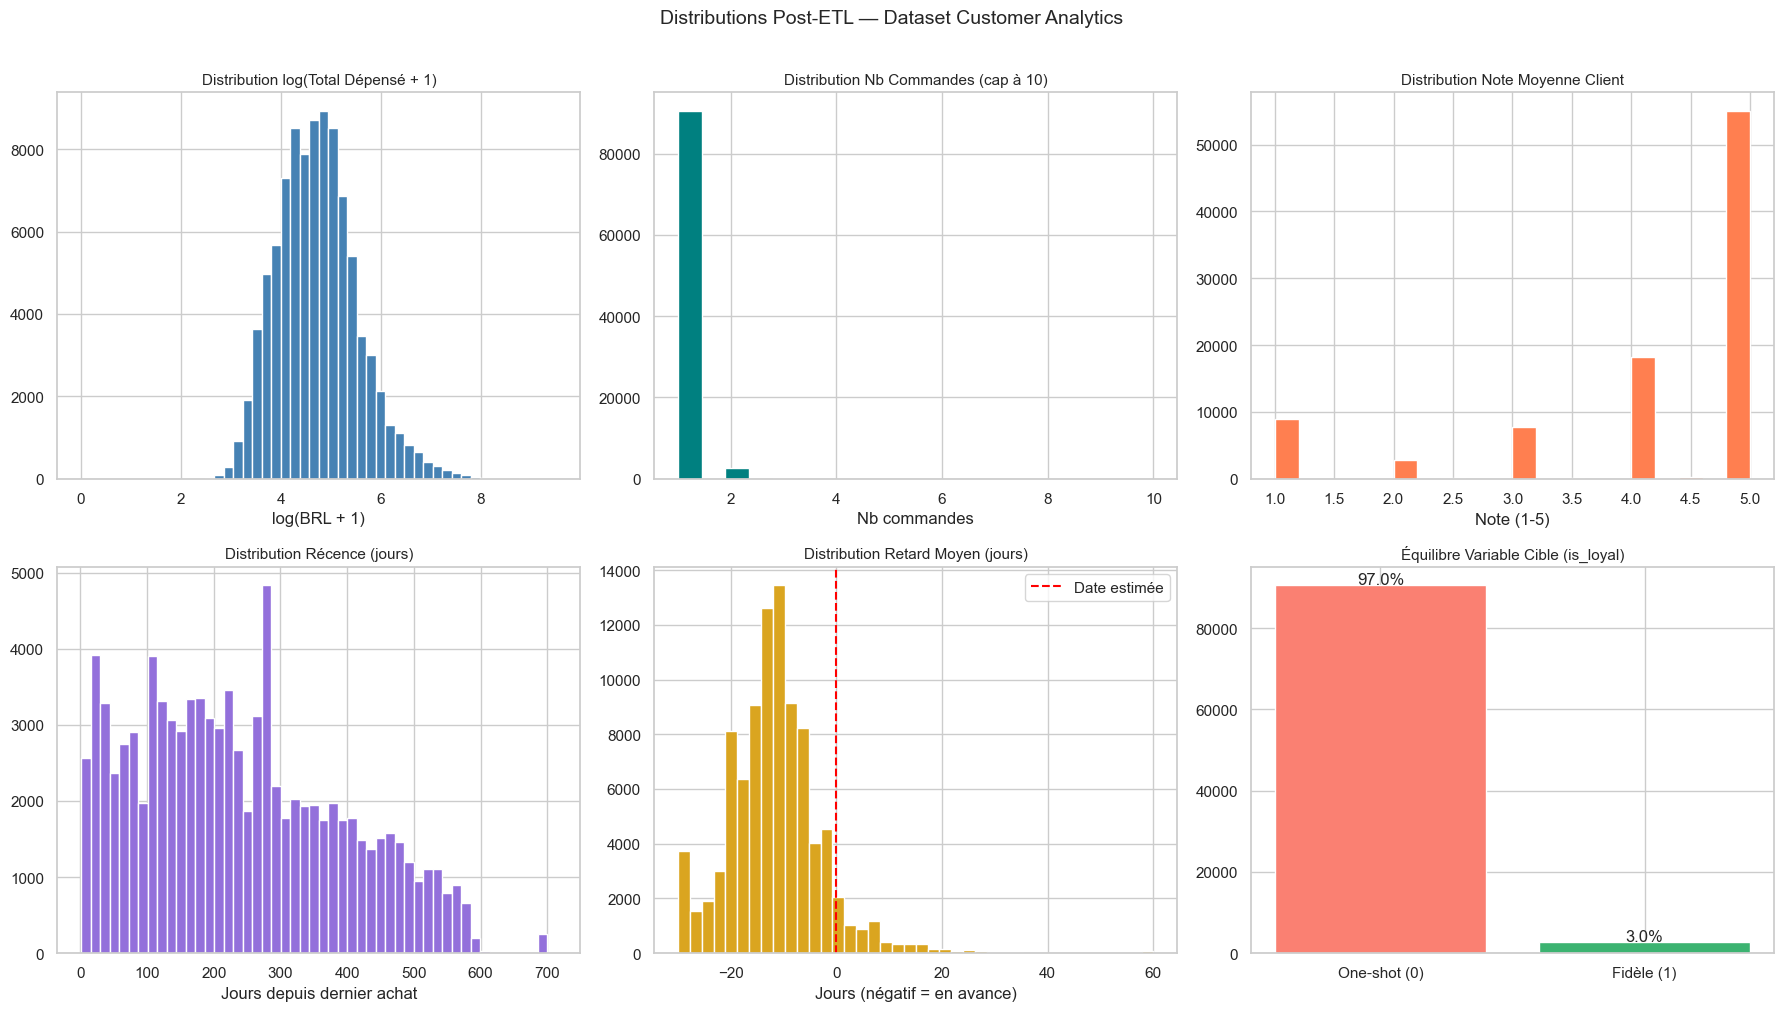

 Graphique sauvegardé : etl_distributions.png


In [22]:
# ============================================================
# VISUALISATION POST-ETL : distributions des variables clés
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution dépense totale (log scale car longue queue)
axes[0, 0].hist(np.log1p(customer_analytics['total_spent']), bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution log(Total Dépensé + 1)', fontsize=11)
axes[0, 0].set_xlabel('log(BRL + 1)')

# 2. Distribution du nombre de commandes
axes[0, 1].hist(customer_analytics['nb_orders'].clip(upper=10), bins=20, color='teal', edgecolor='white')
axes[0, 1].set_title('Distribution Nb Commandes (cap à 10)', fontsize=11)
axes[0, 1].set_xlabel('Nb commandes')

# 3. Distribution note moyenne
axes[0, 2].hist(customer_analytics['avg_review_score'], bins=20, color='coral', edgecolor='white')
axes[0, 2].set_title('Distribution Note Moyenne Client', fontsize=11)
axes[0, 2].set_xlabel('Note (1-5)')

# 4. Distribution récence
axes[1, 0].hist(customer_analytics['recency_days'], bins=50, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Distribution Récence (jours)', fontsize=11)
axes[1, 0].set_xlabel('Jours depuis dernier achat')

# 5. Distribution retard livraison
axes[1, 1].hist(customer_analytics['avg_delay'].clip(-30, 60), bins=40, color='goldenrod', edgecolor='white')
axes[1, 1].set_title('Distribution Retard Moyen (jours)', fontsize=11)
axes[1, 1].set_xlabel('Jours (négatif = en avance)')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Date estimée')
axes[1, 1].legend()

# 6. Équilibre classe cible
loyal_counts = customer_analytics['is_loyal'].value_counts()
axes[1, 2].bar(['One-shot (0)', 'Fidèle (1)'], loyal_counts.values,
                color=['salmon', 'mediumseagreen'], edgecolor='white')
axes[1, 2].set_title('Équilibre Variable Cible (is_loyal)', fontsize=11)
for i, v in enumerate(loyal_counts.values):
    axes[1, 2].text(i, v + 200, f"{v/len(customer_analytics)*100:.1f}%", ha='center')

plt.suptitle('Distributions Post-ETL — Dataset Customer Analytics', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('etl_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique sauvegardé : etl_distributions.png")

### 4.2 Export du dataset final

In [27]:
# ============================================================
# EXPORT DU DATASET ANALYTIQUE FINAL
# ============================================================

# Export CSV (lisible universellement)
customer_analytics.to_csv('customer_analytics.csv', index=False)
print("Exporté : customer_analytics.csv")

# Export Instacart customer features (pour enrichissement ML)
customer_instacart.to_csv('customer_instacart_features.csv', index=False)
print("Exporté : customer_instacart_features.csv")

# Récapitulatif des fichiers produits
print(f"\nLivrables Phase 3 :")
print(f"  customer_analytics.csv           ({customer_analytics.shape[0]:,} clients × {customer_analytics.shape[1]} features)")
print(f"  customer_instacart_features.csv  ({customer_instacart.shape[0]:,} clients × {customer_instacart.shape[1]} features)")

Exporté : customer_analytics.csv
Exporté : customer_instacart_features.csv

Livrables Phase 3 :
  customer_analytics.csv           (93,350 clients × 19 features)
  customer_instacart_features.csv  (206,209 clients × 7 features)


In [28]:
# ============================================================
# APERÇU FINAL DU DATASET
# ============================================================

print("\n Schéma du dataset analytique final :")
print()

schema = pd.DataFrame({
    'Colonne'     : customer_analytics.columns,
    'Type'        : customer_analytics.dtypes.values,
    'Nb_NaN'      : customer_analytics.isnull().sum().values,
    'Description' : [
        'Identifiant unique client Olist',
        'Jours depuis le dernier achat (Recency)',
        'Nombre total de commandes (Frequency)',
        'Montant total dépensé en BRL (Monetary)',
        'Valeur moyenne d\'une commande (BRL)',
        'Valeur de la commande la plus élevée (BRL)',
        'Nombre moyen d\'articles par commande',
        'Nombre total d\'articles achetés',
        'Délai moyen de livraison (jours)',
        'Retard moyen de livraison (jours, négatif = avance)',
        'Proportion de commandes livrées en retard',
        'Note moyenne des avis clients (1-5)',
        'Durée d\'activité (jours entre 1ère et dernière commande)',
        'Fréquence d\'achat (commandes par mois)',
        'État brésilien du client',
        'Date de la première commande',
        'Date de la dernière commande',
        'Variable cible ML : 1=fidèle, 0=one-shot',
        'Client à forte valeur : 1=au-dessus médiane dépense'
    ]
})

display(schema)


 Schéma du dataset analytique final :



,Colonne,Type,Nb_NaN,Description
0,customer_unique_id,str,0,Identifiant unique client Olist
1,recency_days,int64,0,Jours depuis le dernier achat (Recency)
2,nb_orders,int64,0,Nombre total de commandes (Frequency)
3,total_spent,float64,0,Montant total dépensé en BRL (Monetary)
4,avg_order_value,float64,0,Valeur moyenne d'une commande (BRL)
5,max_order_value,float64,0,Valeur de la commande la plus élevée (BRL)
6,avg_basket_size,float64,0,Nombre moyen d'articles par commande
7,total_items,int64,0,Nombre total d'articles achetés
8,avg_delivery_days,float64,0,Délai moyen de livraison (jours)
9,avg_delay,float64,0,"Retard moyen de livraison (jours, négatif = av..."


In [32]:
# ============================================================
# VERIFICATION GLOBALE — Phases 1, 2, 3
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("  VERIFICATION FINALE — PHASES 1, 2, 3")
print("=" * 60)

errors   = []
warnings = []

# ============================================================
# 1. VERIFICATION DES DATASETS BRUTS (Phase 2)
# ============================================================
print("\n[1] DATASETS BRUTS")

raw_checks = {
    "olist_customers"         : (olist_customers,          96000,  5),
    "olist_orders"            : (olist_orders,             99000,  8),
    "olist_items"             : (olist_items,             110000,  7),
    "olist_payments"          : (olist_payments,          100000,  5),
    "olist_reviews"           : (olist_reviews,            98000,  7),
    "olist_products"          : (olist_products,           32000,  9),
    "insta_orders"            : (insta_orders,           3000000,  7),
    "insta_order_products"    : (insta_order_products,   1000000,  4),
    "amazon_reviews"          : (amazon_reviews,            1000,  1),
}

for name, (df, min_rows, min_cols) in raw_checks.items():
    row_ok = df.shape[0] >= min_rows
    col_ok = df.shape[1] >= min_cols
    status = "OK" if (row_ok and col_ok) else "FAIL"
    if status == "FAIL":
        errors.append(f"{name} : shape inattendu {df.shape}")
    print(f"  {'✓' if status=='OK' else '✗'} {name:35} {str(df.shape):15} {status}")

# ============================================================
# 2. VERIFICATION DU DATASET ANALYTIQUE FINAL (Phase 3)
# ============================================================
print("\n[2] DATASET ANALYTIQUE : customer_analytics")

# Chargement depuis CSV pour vérifier l'export
ca = pd.read_csv('customer_analytics.csv')

# 2.1 Dimensions minimales
min_clients = 90000
if ca.shape[0] < min_clients:
    errors.append(f"customer_analytics : trop peu de clients ({ca.shape[0]:,})")
    print(f"  ✗ Nb clients : {ca.shape[0]:,} (attendu ≥ {min_clients:,})")
else:
    print(f"  ✓ Nb clients : {ca.shape[0]:,}")

# 2.2 Colonnes obligatoires
required_cols = [
    'customer_unique_id', 'recency_days', 'nb_orders', 'total_spent',
    'avg_order_value', 'avg_basket_size', 'avg_delivery_days',
    'avg_delay', 'late_rate', 'avg_review_score',
    'purchase_frequency', 'is_loyal', 'is_high_value'
]
missing_cols = [c for c in required_cols if c not in ca.columns]
if missing_cols:
    errors.append(f"Colonnes manquantes : {missing_cols}")
    print(f"  ✗ Colonnes manquantes : {missing_cols}")
else:
    print(f"  ✓ Toutes les colonnes obligatoires présentes ({len(required_cols)})")

# 2.3 Valeurs manquantes
total_missing = ca.isnull().sum().sum()
if total_missing > 0:
    warnings.append(f"Valeurs manquantes résiduelles : {total_missing}")
    print(f"  ⚠ Valeurs manquantes : {total_missing}")
    print(ca.isnull().sum()[ca.isnull().sum() > 0])
else:
    print(f"  ✓ Aucune valeur manquante")

# 2.4 Doublons sur clé client
n_dup = ca['customer_unique_id'].duplicated().sum()
if n_dup > 0:
    errors.append(f"Doublons customer_unique_id : {n_dup}")
    print(f"  ✗ Doublons customer_unique_id : {n_dup}")
else:
    print(f"  ✓ Aucun doublon sur customer_unique_id")

# 2.5 Variable cible is_loyal
if set(ca['is_loyal'].unique()) != {0, 1}:
    errors.append("is_loyal contient des valeurs hors {0, 1}")
    print(f"  ✗ is_loyal valeurs : {ca['is_loyal'].unique()}")
else:
    loyal_rate = ca['is_loyal'].mean() * 100
    print(f"  ✓ is_loyal OK — taux fidélisation : {loyal_rate:.1f}%")
    if loyal_rate > 50:
        warnings.append(f"Taux fidélisation élevé ({loyal_rate:.1f}%) — vérifier la logique is_loyal")

# 2.6 Cohérence des valeurs numériques
checks_range = {
    'recency_days'      : (0, 1000),
    'nb_orders'         : (1, 500),
    'total_spent'       : (0, 1000000),
    'avg_review_score'  : (1, 5),
    'late_rate'         : (0, 1),
    'avg_delivery_days' : (0, 365),
}

print("\n  Plages de valeurs :")
for col, (vmin, vmax) in checks_range.items():
    if col not in ca.columns:
        continue
    col_min = ca[col].min()
    col_max = ca[col].max()
    ok = (col_min >= vmin) and (col_max <= vmax)
    status = "✓" if ok else "⚠"
    if not ok:
        warnings.append(f"{col} hors plage attendue : [{col_min:.2f}, {col_max:.2f}]")
    print(f"    {status} {col:25} min={col_min:.2f}  max={col_max:.2f}  (attendu [{vmin}, {vmax}])")

# ============================================================
# 3. VERIFICATION INSTACART FEATURES (Phase 3)
# ============================================================
print("\n[3] DATASET : customer_instacart_features")

ci = pd.read_csv('customer_instacart_features.csv')

if ci.shape[0] < 200000:
    errors.append(f"customer_instacart_features : trop peu de clients ({ci.shape[0]:,})")
    print(f"  ✗ Nb clients : {ci.shape[0]:,} (attendu ≥ 200 000)")
else:
    print(f"  ✓ Nb clients : {ci.shape[0]:,}")

insta_required = ['user_id', 'insta_nb_orders', 'insta_avg_days_between',
                   'insta_avg_basket_size', 'insta_reorder_rate']
missing_insta = [c for c in insta_required if c not in ci.columns]
if missing_insta:
    errors.append(f"Colonnes Instacart manquantes : {missing_insta}")
    print(f"  ✗ Colonnes manquantes : {missing_insta}")
else:
    print(f"  ✓ Colonnes obligatoires présentes")

# ============================================================
# 4. RAPPORT FINAL
# ============================================================
print("\n" + "=" * 60)
print("  RAPPORT FINAL")
print("=" * 60)

if errors:
    print(f"\n✗ ERREURS ({len(errors)}) — à corriger avant Phase 4 :")
    for e in errors:
        print(f"   • {e}")
else:
    print(f"\n✓ Aucune erreur critique")

if warnings:
    print(f"\n⚠ AVERTISSEMENTS ({len(warnings)}) — à vérifier :")
    for w in warnings:
        print(f"   • {w}")
else:
    print(f"✓ Aucun avertissement")

if not errors:
    print("\n✓ Phases 1-2-3 validées — prêt pour Phase 4 (EDA)")
else:
    print("\n✗ Corriger les erreurs avant de continuer")

# ============================================================
# 5. APERCU STATISTIQUE RAPIDE
# ============================================================
print("\n[5] STATISTIQUES CLÉS — customer_analytics")
print(ca[['recency_days','nb_orders','total_spent',
          'avg_review_score','late_rate','is_loyal']].describe().round(2).to_string())

  VERIFICATION FINALE — PHASES 1, 2, 3

[1] DATASETS BRUTS
  ✓ olist_customers                     (99441, 5)      OK
  ✓ olist_orders                        (99441, 8)      OK
  ✓ olist_items                         (112650, 7)     OK
  ✓ olist_payments                      (103886, 5)     OK
  ✓ olist_reviews                       (98410, 7)      OK
  ✓ olist_products                      (32951, 9)      OK
  ✓ insta_orders                        (3421083, 7)    OK
  ✓ insta_order_products                (32434489, 4)   OK
  ✓ amazon_reviews                      (4915, 12)      OK

[2] DATASET ANALYTIQUE : customer_analytics
  ✓ Nb clients : 93,350
  ✓ Toutes les colonnes obligatoires présentes (13)
  ✓ Aucune valeur manquante
  ✓ Aucun doublon sur customer_unique_id
  ✓ is_loyal OK — taux fidélisation : 3.0%

  Plages de valeurs :
    ✓ recency_days              min=1.00  max=714.00  (attendu [0, 1000])
    ✓ nb_orders                 min=1.00  max=15.00  (attendu [1, 500])
    ✓ to

---
## 5. Conclusion Phase 3

### Ce qui a été accompli

| Étape | Action | Résultat |
|---|---|---|
| **Extract** | Rechargement de 11 tables sources | ✅ |
| **Transform — Nettoyage** | Suppression doublons, conversion dates, filtrage commandes livrées | ✅ |
| **Transform — Jointures** | Customers + Orders + Payments + Reviews + Items | ✅ |
| **Transform — Variables métier** | delivery_delay, is_late, purchase_frequency, is_loyal, is_high_value | ✅ |
| **Transform — Agrégation** | Passage niveau commande → niveau client | ✅ |
| **Load** | Export CSV + Parquet | ✅ |

### Livrables produits
- `customer_analytics.csv` — Dataset analytique principal (1 ligne = 1 client)
- `customer_analytics.parquet` — Même contenu, format optimisé
- `customer_instacart_features.csv` — Métriques comportementales Instacart
- `etl_distributions.png` — Distributions des variables clés

### Prochaine étape → Phase 4 : EDA
Analyse exploratoire approfondie : distributions, corrélations, outliers, visualisations métier.